In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

pd.set_option("display.max_columns", None)

sns.set_theme(style="whitegrid")

# Load processed datasets
df_clean = pd.read_csv("../data/restaurant_cleaned.csv")
df_rated = pd.read_csv("../data/restaurant_rated.csv")

print("Clean dataset:", df_clean.shape)
print("Rated dataset:", df_rated.shape)

Clean dataset: (9551, 21)
Rated dataset: (7403, 25)


In [38]:
df_rated[
    [
        "Restaurant Name",
        "Aggregate rating",
        "Votes",
        "Log Votes",
        "Rating Score",
        "Popularity Score",
        "Performance Score"
    ]
].head(10)

,Restaurant Name,Aggregate rating,Votes,Log Votes,Rating Score,Popularity Score,Performance Score
0,Le Petit Souffle,4.8,314,5.752573,0.967742,0.538749,0.796145
1,Izakaya Kikufuji,4.5,591,6.383507,0.870968,0.620792,0.770897
2,Heat - Edsa Shangri-La,4.4,270,5.602119,0.838710,0.519185,0.710900
3,Ooma,4.9,365,5.902633,1.000000,0.558262,0.823305
4,Sambo Kojin,4.8,229,5.438079,0.967742,0.497854,0.779787
5,Din Tai Fung,4.4,336,5.820083,0.838710,0.547528,0.722237
6,Buffet 101,4.0,520,6.255750,0.709677,0.604179,0.667478
7,Vikings,4.2,677,6.519147,0.774194,0.638430,0.719888
8,Spiral - Sofitel Philippine Plaza Manila,4.9,621,6.432940,1.000000,0.627220,0.850888
9,Locavore,4.8,532,6.278521,0.967742,0.607140,0.823501


In [39]:
top_performers = (
    df_rated[
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Aggregate rating",
            "Votes",
            "Performance Score"
        ]
    ]
    .sort_values("Performance Score", ascending=False)
    .head(20)
)

top_performers

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score
720,Toit,Bangalore,"Italian, American, Pizza",4.8,10934,0.980645
2076,Barbeque Nation,Kolkata,"North Indian, Chinese",4.9,5966,0.968494
1969,AB's - Absolute Barbecues,Hyderabad,"European, Mediterranean, North Indian",4.9,5434,0.963637
727,Truffles,Bangalore,"American, Burger, Cafe",4.7,9667,0.954885
2157,Mirchi And Mime,Mumbai,"North Indian, South Indian, Mughlai",4.9,3244,0.936811
2593,Naturals Ice Cream,New Delhi,Ice Cream,4.9,2620,0.925703
731,AB's - Absolute Barbecues,Bangalore,"European, Mediterranean, North Indian",4.6,6907,0.918046
367,McGuire's Irish Pub & Brewery,Pensacola,"Burger, Bar Food, Steak",4.9,2238,0.917509
7149,Talaga Sampireun,Tangerang,"Sunda, Indonesian",4.9,2212,0.916902
3068,Indian Accent - The Manor,New Delhi,Modern Indian,4.9,1934,0.909920


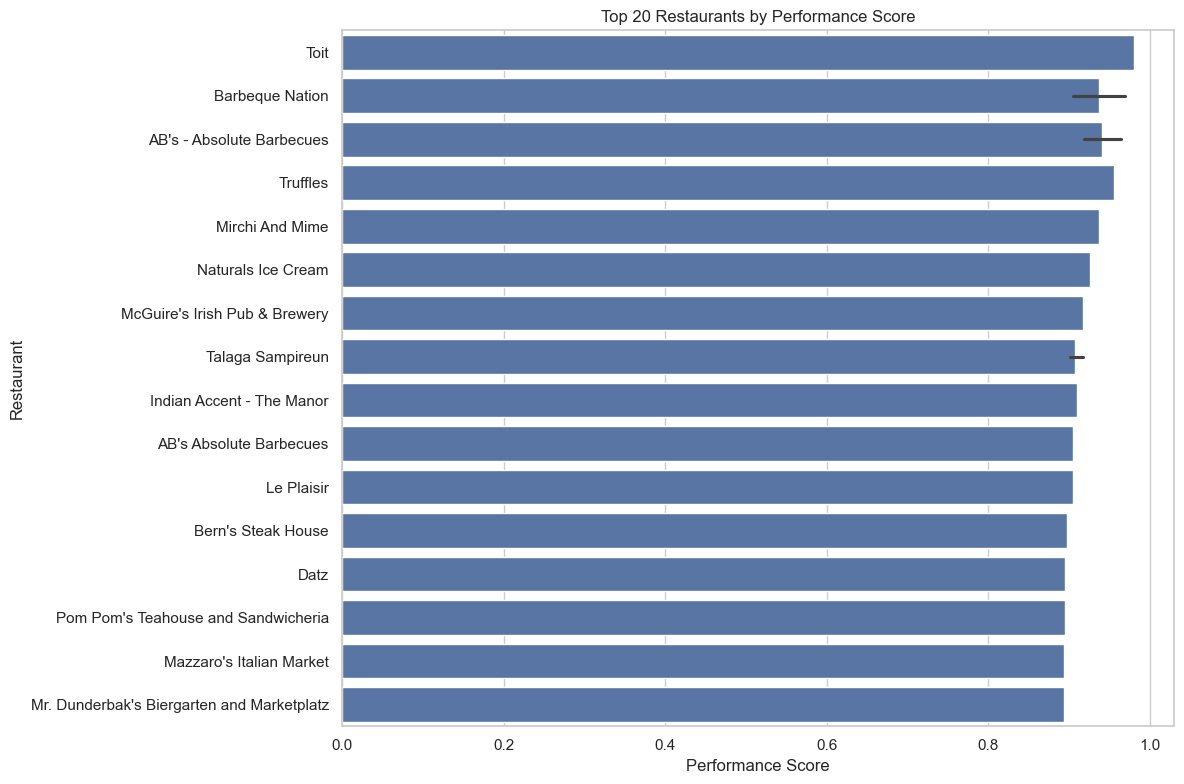

In [40]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=top_performers,
    x="Performance Score",
    y="Restaurant Name"
)

plt.title("Top 20 Restaurants by Performance Score")
plt.xlabel("Performance Score")
plt.ylabel("Restaurant")

plt.tight_layout()
plt.show()

In [41]:
rating_median = df_rated["Aggregate rating"].median()
votes_median = df_rated["Log Votes"].median()

print("Rating Median:", rating_median)
print("Log Votes Median:", votes_median)

Rating Median: 3.4
Log Votes Median: 4.110873864173311


In [42]:
def classify_restaurant(row):

    high_rating = row["Aggregate rating"] >= rating_median
    high_engagement = row["Log Votes"] >= votes_median

    if high_rating and high_engagement:
        return "High Performer"

    elif high_rating and not high_engagement:
        return "Hidden Gem"

    elif not high_rating and high_engagement:
        return "Popular but Average"

    else:
        return "Needs Improvement"


df_rated["Performance Segment"] = (
    df_rated.apply(classify_restaurant, axis=1)
)

In [43]:
segment_counts = (
    df_rated["Performance Segment"]
    .value_counts()
)

segment_counts

Performance Segment
High Performer         3043
Needs Improvement      2761
Hidden Gem              935
Popular but Average     664
Name: count, dtype: int64

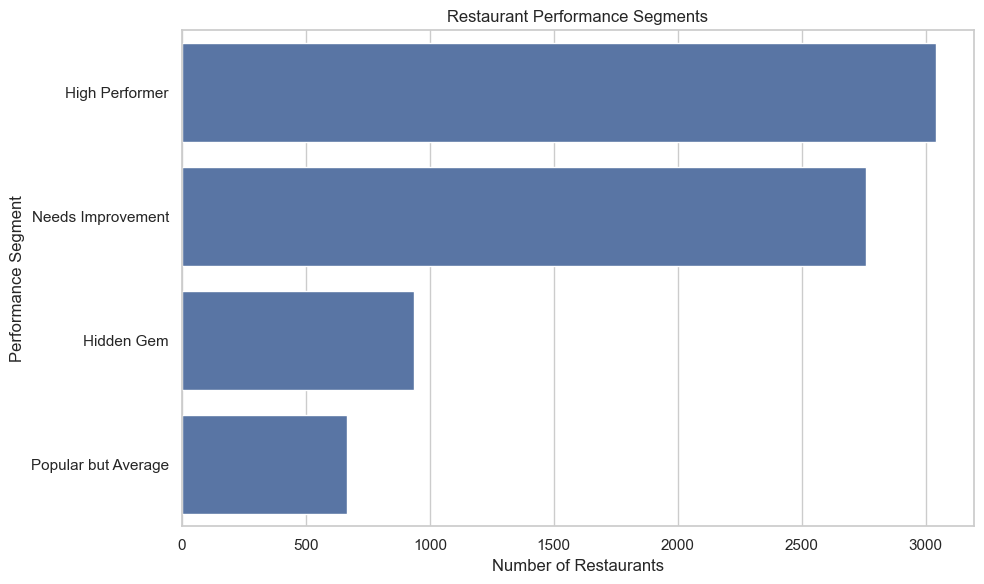

In [44]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_rated,
    y="Performance Segment",
    order=segment_counts.index
)

plt.title("Restaurant Performance Segments")
plt.xlabel("Number of Restaurants")
plt.ylabel("Performance Segment")

plt.tight_layout()
plt.show()

In [45]:

segment_top = (
    df_rated
    .sort_values(
        ["Performance Segment", "Performance Score"],
        ascending=[True, False]
    )
    .groupby("Performance Segment")
    .head(10)
)

segment_top[
    [
        "Performance Segment",
        "Restaurant Name",
        "City",
        "Cuisines",
        "Aggregate rating",
        "Votes",
        "Performance Score"
    ]
]

,Performance Segment,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score
842,Hidden Gem,The Great Indian Pub,Dehradun,North Indian,4.9,50,0.720796
49,Hidden Gem,Garota de Ipanema,Rio de Janeiro,"Brazilian, Bar Food",4.9,49,0.719766
64,Hidden Gem,Skye - Hotel Unique,S��o Paulo,"Beverages, International",4.8,59,0.709894
47,Hidden Gem,Braseiro da G��vea,Rio de Janeiro,"Brazilian, Bar Food",4.9,40,0.709444
38,Hidden Gem,Coco Bambu,Bras�_lia,International,4.9,30,0.694902
2592,Hidden Gem,MOB Brewpub,New Delhi,"Continental, Italian, Asian, Indian",4.7,52,0.684087
57,Hidden Gem,Apraz�_vel,Rio de Janeiro,Brazilian,4.7,44,0.675576
42,Hidden Gem,Confeitaria Colombo,Rio de Janeiro,"Desserts, Cafe",4.8,29,0.673841
75,Hidden Gem,Veloso,S��o Paulo,"Brazilian, Bar Food, Beverages",4.6,58,0.670310
46,Hidden Gem,TT Burger,Rio de Janeiro,Burger,4.8,19,0.652751


In [46]:
hidden_gems = (
    df_rated[
        df_rated["Performance Segment"] == "Hidden Gem"
    ]
    .sort_values(
        "Aggregate rating",
        ascending=False
    )
    .head(20)
)

hidden_gems[
    [
        "Restaurant Name",
        "City",
        "Cuisines",
        "Aggregate rating",
        "Votes",
        "Performance Score"
    ]
]

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score
842,The Great Indian Pub,Dehradun,North Indian,4.9,50,0.720796
49,Garota de Ipanema,Rio de Janeiro,"Brazilian, Bar Food",4.9,49,0.719766
47,Braseiro da G��vea,Rio de Janeiro,"Brazilian, Bar Food",4.9,40,0.709444
38,Coco Bambu,Bras�_lia,International,4.9,30,0.694902
42,Confeitaria Colombo,Rio de Janeiro,"Desserts, Cafe",4.8,29,0.673841
64,Skye - Hotel Unique,S��o Paulo,"Beverages, International",4.8,59,0.709894
46,TT Burger,Rio de Janeiro,Burger,4.8,19,0.652751
57,Apraz�_vel,Rio de Janeiro,Brazilian,4.7,44,0.675576
2592,MOB Brewpub,New Delhi,"Continental, Italian, Asian, Indian",4.7,52,0.684087
43,Bibi,Rio de Janeiro,"Juices, Healthy Food",4.7,24,0.645003


In [47]:
popular_average = (
    df_rated[
        df_rated["Performance Segment"] == "Popular but Average"
    ]
    .sort_values(
        "Votes",
        ascending=False
    )
    .head(20)
)

popular_average[
    [
        "Restaurant Name",
        "City",
        "Cuisines",
        "Aggregate rating",
        "Votes",
        "Performance Score"
    ]
]

,Restaurant Name,City,Cuisines,Aggregate rating,Votes,Performance Score
2588,My Bar Lounge & Restaurant,New Delhi,"North Indian, Chinese, Italian, Continental",2.7,2460,0.496620
1119,The Wine Company,Gurgaon,"Italian, European",2.4,2412,0.437531
3359,My Bar Grill,New Delhi,"North Indian, Italian, Continental, Chinese",3.3,1363,0.582054
2587,Indian Coffee House,New Delhi,Fast Food,3.3,1300,0.579594
428,The Lady & Sons,Savannah,Southern,3.3,1201,0.575477
2582,Castle 9,New Delhi,"Finger Food, Continental, North Indian, Chinese",3.1,1099,0.532155
2589,My Bar Square,New Delhi,"North Indian, Chinese, Italian, Continental",2.5,1096,0.415884
6999,Le Cafe,Puducherry,Cafe,3.1,875,0.520312
1091,Fatburger,Gurgaon,"American, Mexican",3.3,793,0.553909
6945,Pind Balluchi,Noida,"North Indian, Mughlai",3.3,793,0.553909


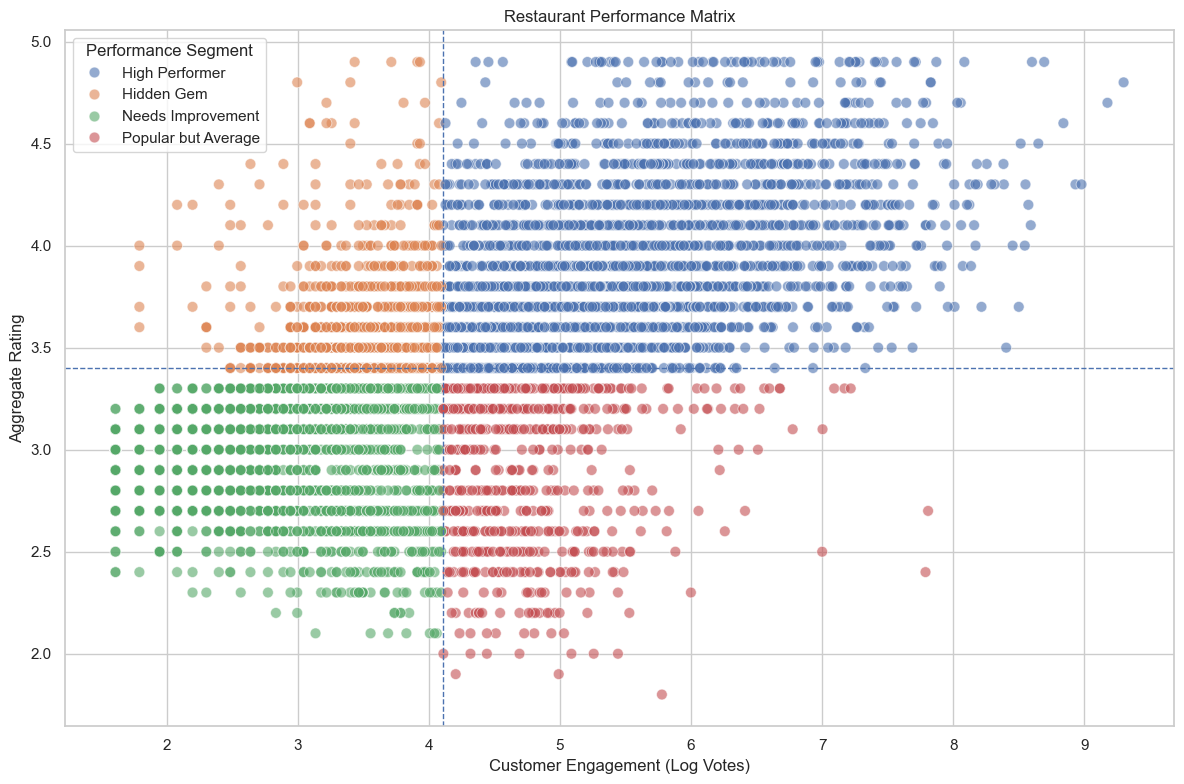

In [48]:

plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=df_rated,
    x="Log Votes",
    y="Aggregate rating",
    hue="Performance Segment",
    alpha=0.6,
    s=60
)

# Add benchmark lines
plt.axvline(
    votes_median,
    linestyle="--",
    linewidth=1
)

plt.axhline(
    rating_median,
    linestyle="--",
    linewidth=1
)

plt.title("Restaurant Performance Matrix")
plt.xlabel("Customer Engagement (Log Votes)")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

In [49]:
segment_summary = (
    df_rated
    .groupby("Performance Segment")
    .agg(
        Restaurants=("Restaurant Name", "count"),
        Avg_Rating=("Aggregate rating", "mean"),
        Avg_Votes=("Votes", "mean"),
        Avg_Performance_Score=("Performance Score", "mean")
    )
    .reset_index()
    .sort_values(
        "Avg_Performance_Score",
        ascending=False
    )
)

segment_summary

,Performance Segment,Restaurants,Avg_Rating,Avg_Votes,Avg_Performance_Score
1,High Performer,3043,3.921919,431.901742,0.614603
0,Hidden Gem,935,3.629947,34.451337,0.451765
3,Popular but Average,664,2.898946,149.243976,0.376912
2,Needs Improvement,2761,2.974719,18.540022,0.285579


In [50]:
segment_summary.to_csv(
    "../data/restaurant_segment_summary.csv",
    index=False
)

print("Segment analysis saved.")

Segment analysis saved.


In [51]:

value_df = df_rated.dropna(
    subset=["Average Cost for two"]
).copy()

scaler = MinMaxScaler()

value_df[
    ["Rating_Normalized", "Cost_Normalized"]
] = scaler.fit_transform(
    value_df[
        [
            "Aggregate rating",
            "Average Cost for two"
        ]
    ]
)

value_df["Value Score"] = (
    0.70 * value_df["Rating_Normalized"]
    +
    0.30 * (1 - value_df["Cost_Normalized"])
)

In [52]:
best_value = (
    value_df[
        [
            "Restaurant Name",
            "City",
            "Cuisines",
            "Average Cost for two",
            "Aggregate rating",
            "Votes",
            "Value Score"
        ]
    ]
    .sort_values(
        "Value Score",
        ascending=False
    )
    .head(20)
)

best_value

,Restaurant Name,City,Cuisines,Average Cost for two,Aggregate rating,Votes,Value Score
499,Mazzaro's Italian Market,Tampa Bay,"Italian, Deli",10.0,4.9,1424,0.999999
170,Shorts Burger and Shine,Cedar Rapids/Iowa City,Burger,10.0,4.9,820,0.999999
208,Oakwood Cafe,Dalton,"BBQ, Breakfast, Southern",10.0,4.9,249,0.999999
421,Marukame Udon,Rest of Hawaii,Japanese,10.0,4.9,602,0.999999
317,Ingleside Village Pizza,Macon,"Pizza, Sandwich",10.0,4.9,478,0.999999
7240,Bao,London,"Taiwanese, Street Food",20.0,4.9,161,0.999995
7156,Miann,Auckland,Desserts,25.0,4.9,281,0.999993
297,Atlanta Highway Seafood Market,Gainesville,"Sandwich, Seafood, Cajun",25.0,4.9,681,0.999993
355,Pom Pom's Teahouse and Sandwicheria,Orlando,"American, Sandwich, Tea",25.0,4.9,1457,0.999993
243,The Cafe,Des Moines,"American, Coffee and Tea",25.0,4.9,570,0.999993


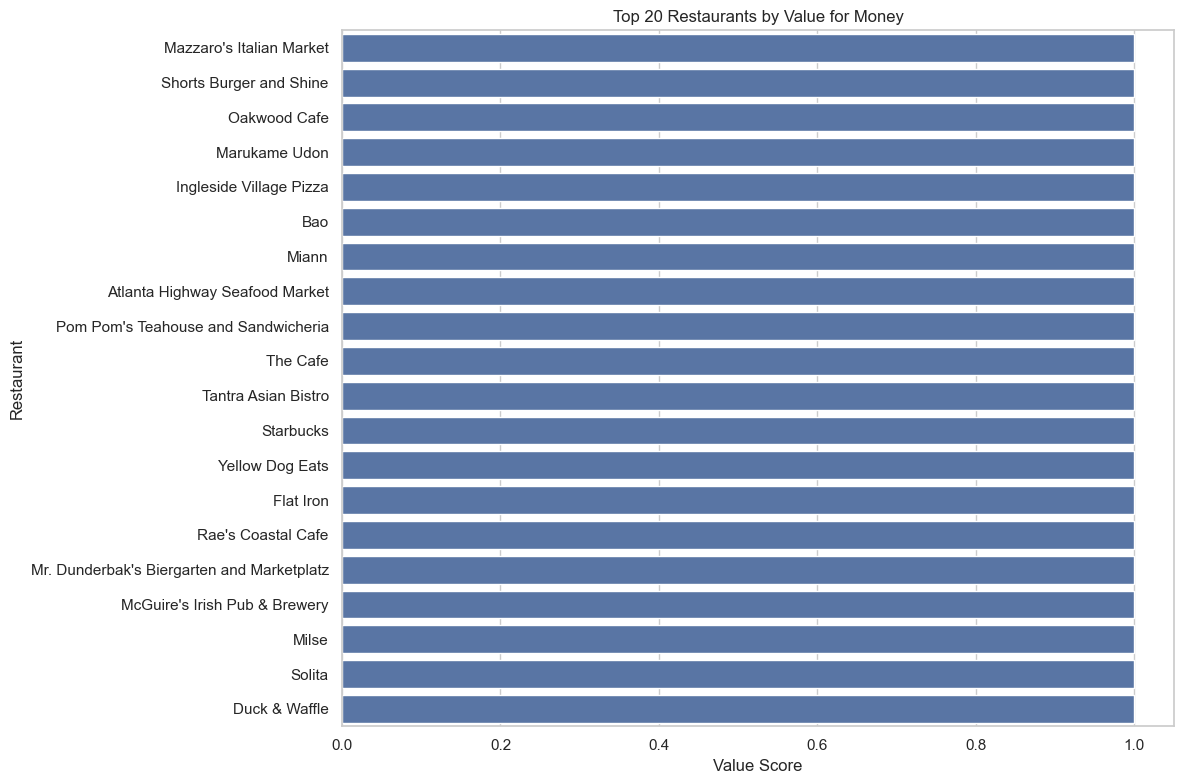

In [53]:
plt.figure(figsize=(12, 8))

sns.barplot(
    data=best_value,
    x="Value Score",
    y="Restaurant Name"
)

plt.title("Top 20 Restaurants by Value for Money")
plt.xlabel("Value Score")
plt.ylabel("Restaurant")

plt.tight_layout()
plt.show()

In [54]:

value_by_price = (
    value_df
    .groupby("Price range")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Cost=("Average Cost for two", "mean"),
        Average_Value_Score=("Value Score", "mean"),
        Average_Votes=("Votes", "mean")
    )
    .reset_index()
)

value_by_price

,Price range,Restaurant_Count,Average_Rating,Average_Cost,Average_Value_Score,Average_Votes
0,1,2726,3.235437,287.070066,0.624026,71.657740
1,2,2711,3.377167,601.224640,0.655912,169.347473
2,3,1373,3.777276,5281.652586,0.744504,455.142025
3,4,575,3.890957,1840.756522,0.771464,375.624348


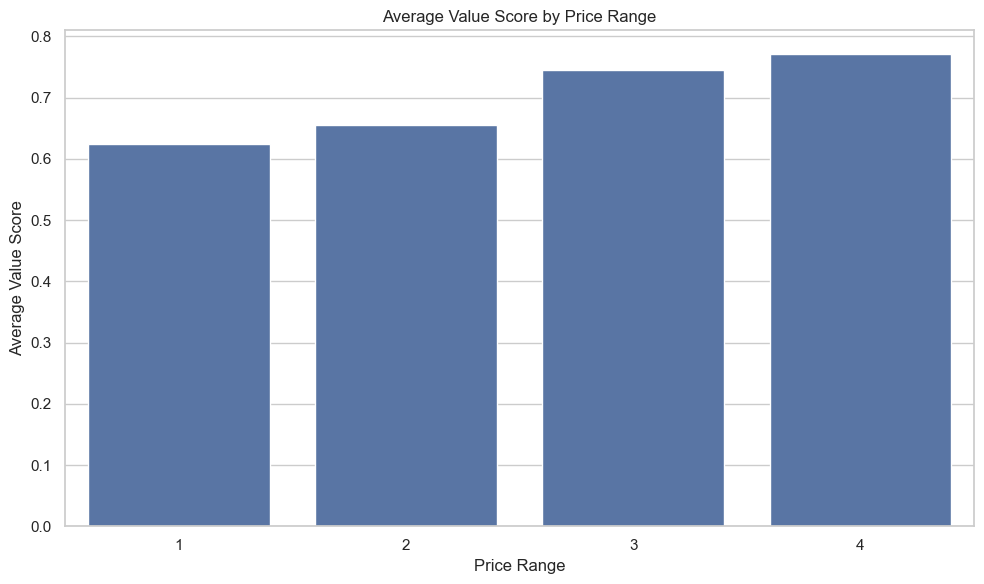

In [55]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=value_by_price,
    x="Price range",
    y="Average_Value_Score"
)

plt.title("Average Value Score by Price Range")
plt.xlabel("Price Range")
plt.ylabel("Average Value Score")

plt.tight_layout()
plt.show()

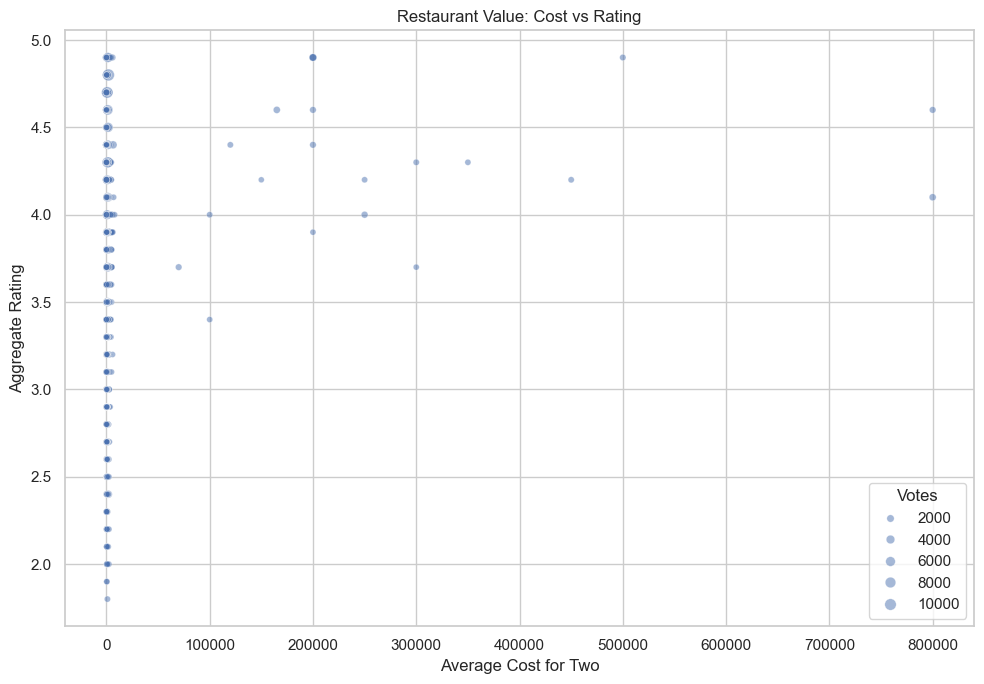

In [56]:
plt.figure(figsize=(10, 7))

sns.scatterplot(
    data=value_df,
    x="Average Cost for two",
    y="Aggregate rating",
    size="Votes",
    alpha=0.5
)

plt.title("Restaurant Value: Cost vs Rating")
plt.xlabel("Average Cost for Two")
plt.ylabel("Aggregate Rating")

plt.tight_layout()
plt.show()

In [57]:

delivery_analysis = (
    df_rated
    .groupby("Has Online delivery")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Average_Performance_Score=("Performance Score", "mean")
    )
    .reset_index()
)

delivery_analysis

,Has Online delivery,Restaurant_Count,Average_Rating,Average_Votes,Average_Performance_Score
0,No,5048,3.467433,193.940174,0.447923
1,Yes,2355,3.381274,219.858174,0.454469


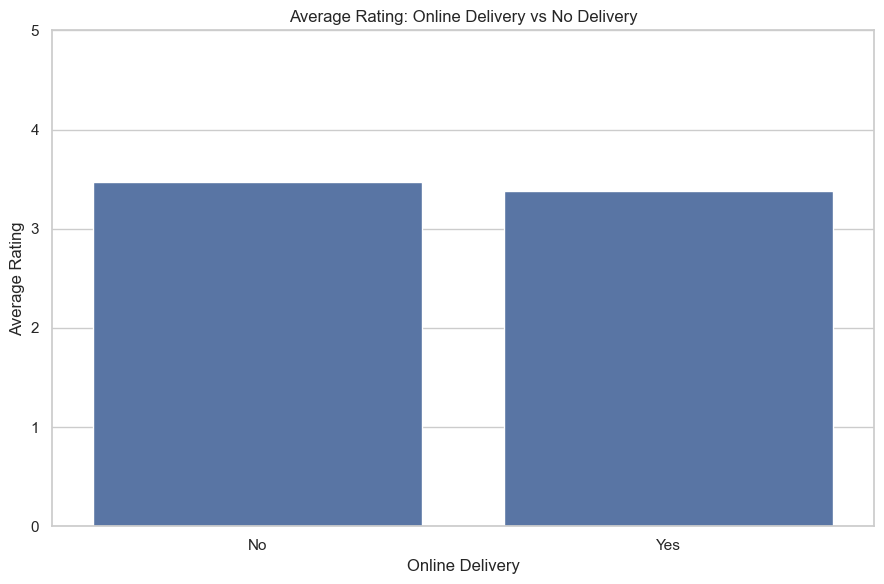

In [58]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=delivery_analysis,
    x="Has Online delivery",
    y="Average_Rating"
)

plt.title("Average Rating: Online Delivery vs No Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Rating")

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

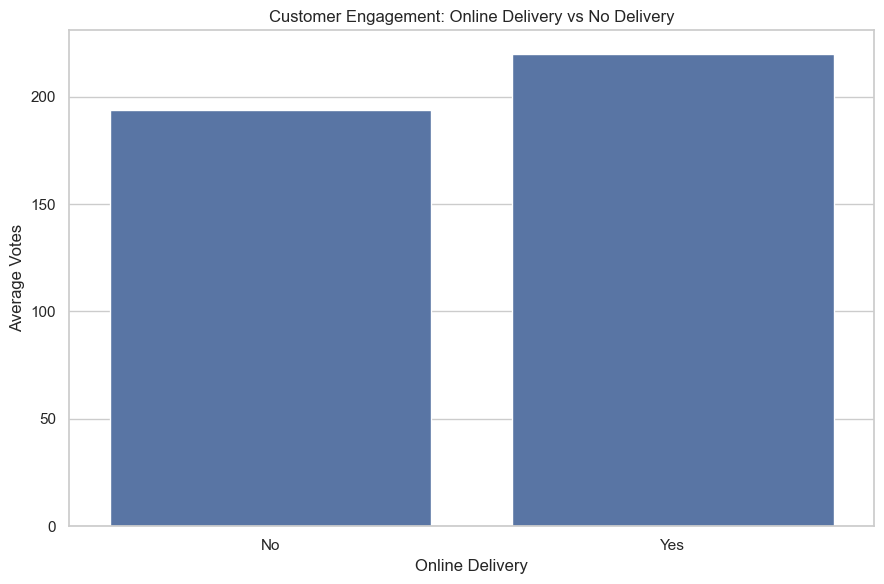

In [59]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=delivery_analysis,
    x="Has Online delivery",
    y="Average_Votes"
)

plt.title("Customer Engagement: Online Delivery vs No Delivery")
plt.xlabel("Online Delivery")
plt.ylabel("Average Votes")

plt.tight_layout()
plt.show()

In [60]:
delivery_rating_difference = (
    delivery_analysis.loc[
        delivery_analysis["Has Online delivery"] == "Yes",
        "Average_Rating"
    ].iloc[0]
    -
    delivery_analysis.loc[
        delivery_analysis["Has Online delivery"] == "No",
        "Average_Rating"
    ].iloc[0]
)

print(
    f"Rating difference between delivery and non-delivery restaurants: "
    f"{delivery_rating_difference:.3f}"
)

Rating difference between delivery and non-delivery restaurants: -0.086


In [61]:

booking_analysis = (
    df_rated
    .groupby("Has Table booking")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Average_Performance_Score=("Performance Score", "mean")
    )
    .reset_index()
)

booking_analysis

,Has Table booking,Restaurant_Count,Average_Rating,Average_Votes,Average_Performance_Score
0,No,6292,3.413970,172.905912,0.437010
1,Yes,1111,3.587579,368.003600,0.523603


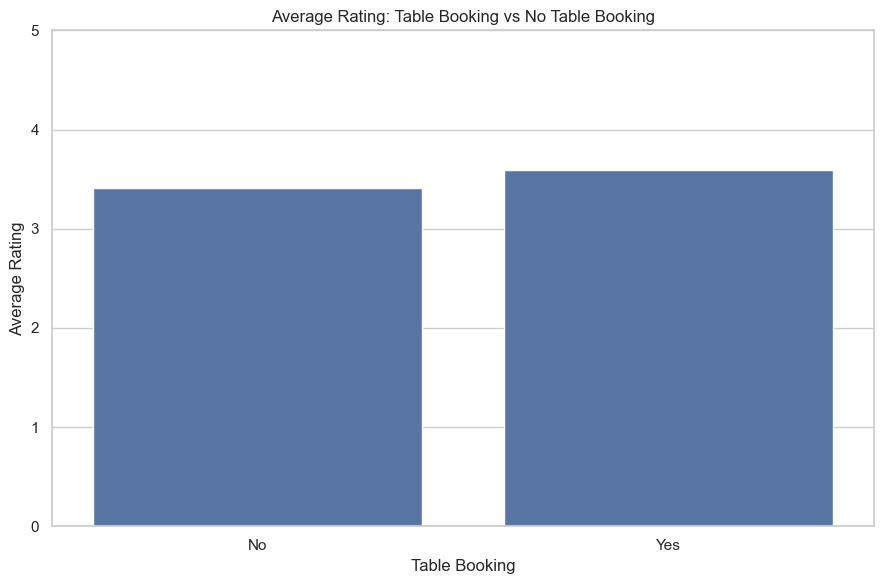

In [62]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=booking_analysis,
    x="Has Table booking",
    y="Average_Rating"
)

plt.title("Average Rating: Table Booking vs No Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Rating")

plt.ylim(0, 5)
plt.tight_layout()
plt.show()

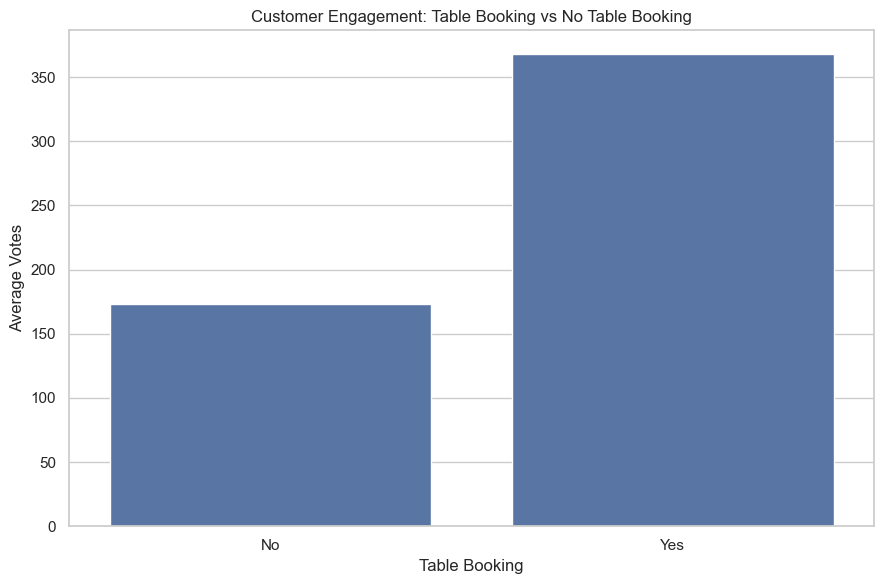

In [63]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=booking_analysis,
    x="Has Table booking",
    y="Average_Votes"
)

plt.title("Customer Engagement: Table Booking vs No Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Votes")

plt.tight_layout()
plt.show()

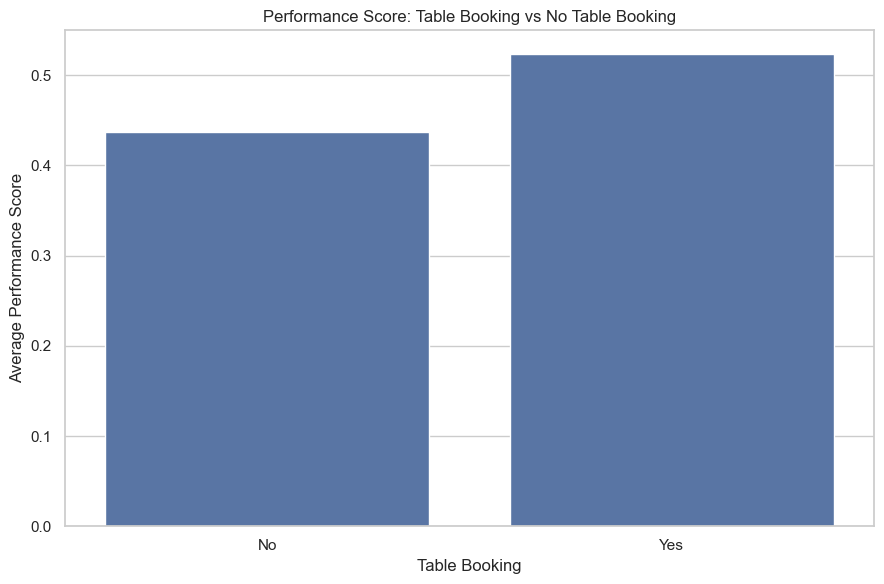

In [64]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=booking_analysis,
    x="Has Table booking",
    y="Average_Performance_Score"
)

plt.title("Performance Score: Table Booking vs No Table Booking")
plt.xlabel("Table Booking")
plt.ylabel("Average Performance Score")

plt.tight_layout()
plt.show()

In [65]:

df_rated["Digital Adoption"] = (
    df_rated["Has Online delivery"].map({"Yes": 1, "No": 0})
    +
    df_rated["Has Table booking"].map({"Yes": 1, "No": 0})
)

df_rated["Digital Adoption"] = df_rated["Digital Adoption"].map({
    0: "Neither",
    1: "One Service",
    2: "Both Services"
})

digital_adoption = (
    df_rated
    .groupby("Digital Adoption")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean"),
        Average_Votes=("Votes", "mean"),
        Average_Performance=("Performance Score", "mean")
    )
    .reset_index()
)

digital_adoption

,Digital Adoption,Restaurant_Count,Average_Rating,Average_Votes,Average_Performance
0,Both Services,433,3.612471,476.491917,0.553641
1,Neither,4370,3.451259,177.683982,0.439158
2,One Service,2600,3.392423,197.683077,0.450978


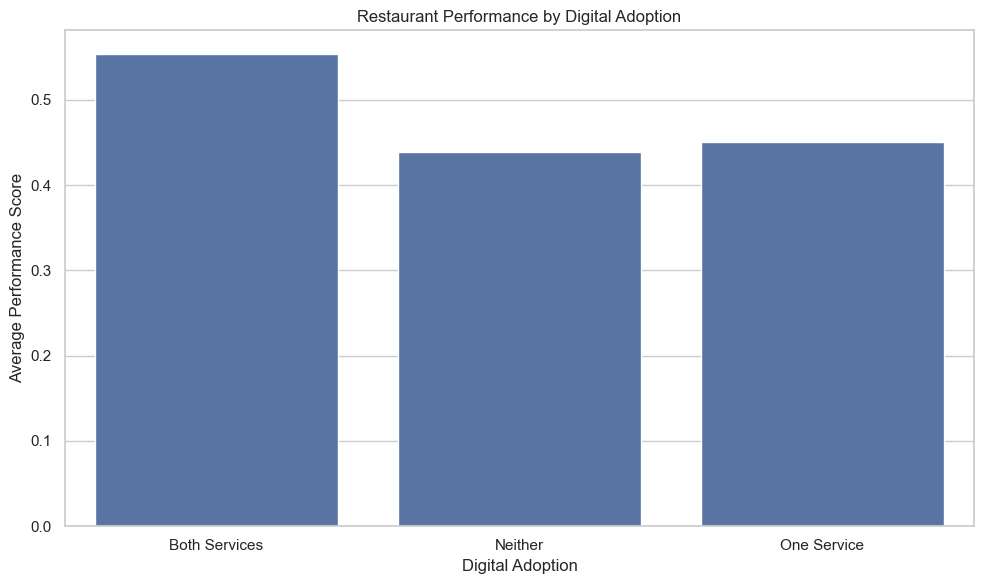

In [66]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=digital_adoption,
    x="Digital Adoption",
    y="Average_Performance"
)

plt.title("Restaurant Performance by Digital Adoption")
plt.xlabel("Digital Adoption")
plt.ylabel("Average Performance Score")

plt.tight_layout()
plt.show()

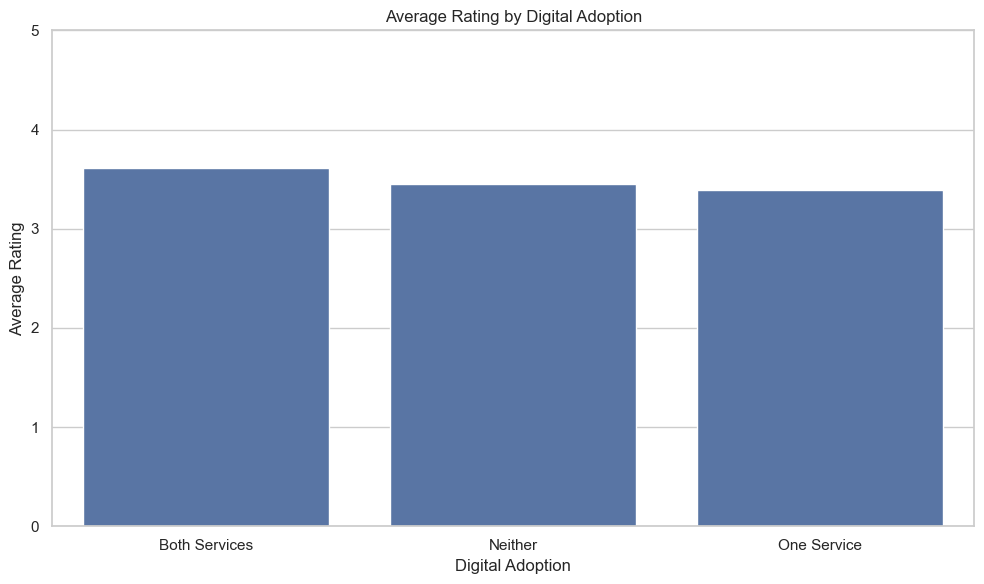

In [67]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=digital_adoption,
    x="Digital Adoption",
    y="Average_Rating"
)

plt.title("Average Rating by Digital Adoption")
plt.xlabel("Digital Adoption")
plt.ylabel("Average Rating")

plt.ylim(0, 5)

plt.tight_layout()
plt.show()

In [68]:

cuisine_series = (
    df_clean["Cuisines"]
    .dropna()
    .str.split(",")
    .explode()
    .str.strip()
)

business_summary = {
    "Total Restaurants": len(df_clean),
    "Rated Restaurants": len(df_rated),
    "Unrated Restaurants": len(df_clean) - len(df_rated),
    "Average Rating": df_rated["Aggregate rating"].mean(),
    "Median Rating": df_rated["Aggregate rating"].median(),
    "Average Votes": df_rated["Votes"].mean(),
    "Most Common City": df_clean["City"].value_counts().idxmax(),
    "Most Common Cuisine": cuisine_series.value_counts().idxmax(),
    "Most Common Price Range": df_clean["Price range"].mode()[0]
}

business_summary

{'Total Restaurants': 9551,
 'Rated Restaurants': 7403,
 'Unrated Restaurants': 2148,
 'Average Rating': 3.440024314467108,
 'Median Rating': 3.4,
 'Average Votes': 202.1850601107659,
 'Most Common City': 'New Delhi',
 'Most Common Cuisine': 'North Indian',
 'Most Common Price Range': 1}

In [69]:

city_performance = (
    df_rated
    .groupby("City")
    .agg(
        Restaurant_Count=("Restaurant Name", "count"),
        Average_Rating=("Aggregate rating", "mean")
    )
    .reset_index()
)

city_performance_filtered = city_performance[
    city_performance["Restaurant_Count"] >= 30
].copy()

city_performance_filtered

,City,Restaurant_Count,Average_Rating
43,Faridabad,151,3.103311
50,Gurgaon,890,3.330674
88,New Delhi,4048,3.297381
89,Noida,696,3.159626


In [70]:

highest_rated_city = (
    city_performance_filtered
    .sort_values("Average_Rating", ascending=False)
    .iloc[0]
)

best_value_restaurant = (
    best_value.iloc[0]
)

largest_segment = (
    segment_counts.idxmax()
)

best_digital_group = (
    digital_adoption
    .sort_values("Average_Performance", ascending=False)
    .iloc[0]
)

print("KEY BUSINESS INSIGHTS")
print("=" * 60)

print(
    f"1. The dataset contains {len(df_clean):,} restaurants, "
    f"of which {len(df_rated):,} have ratings."
)

print(
    f"2. The overall average restaurant rating is "
    f"{df_rated['Aggregate rating'].mean():.2f}."
)

print(
    f"3. {largest_segment} is the largest restaurant "
    f"performance segment."
)

print(
    f"4. {highest_rated_city['City']} has the highest average "
    f"rating among cities with at least 30 rated restaurants "
    f"({highest_rated_city['Average_Rating']:.2f})."
)

print(
    f"5. {best_value_restaurant['Restaurant Name']} has the "
    f"highest calculated Value Score in our analysis."
)

print(
    f"6. The strongest digital-adoption group by average "
    f"Performance Score is '{best_digital_group['Digital Adoption']}'."
)

KEY BUSINESS INSIGHTS
1. The dataset contains 9,551 restaurants, of which 7,403 have ratings.
2. The overall average restaurant rating is 3.44.
3. High Performer is the largest restaurant performance segment.
4. Gurgaon has the highest average rating among cities with at least 30 rated restaurants (3.33).
5. Mazzaro's Italian Market has the highest calculated Value Score in our analysis.
6. The strongest digital-adoption group by average Performance Score is 'Both Services'.


In [71]:

df_rated.to_csv(
    "../data/restaurant_performance_analysis.csv",
    index=False
)

print("Final analytical dataset saved successfully!")

Final analytical dataset saved successfully!
